# Notebook 04 - Feature Engineering: RFM Analysis

## What is RFM?

**RFM** is a customer analytics framework that measures three dimensions of customer behaviour:

| Dimension | Definition | What it measures |
|-----------|-----------|------------------|
| **Recency (R)** | Days since the customer's last purchase | How recently they engaged |
| **Frequency (F)** | Number of unique invoices/orders | How often they buy |
| **Monetary (M)** | Total revenue generated by the customer | How much they spend |

## Why RFM?

RFM is a well-established, interpretable framework for customer segmentation used across retail, e-commerce, and marketing. It requires only transaction data (no surveys or external data), and the three dimensions map naturally to business value:
- **High R, high F, high M** -> Loyal, high-value customers to retain
- **Low R, low F, low M** -> At-risk or lost customers to re-engage

RFM features are also used directly in the purchase prediction model (Notebook 07).

## Reference date

Recency is calculated relative to the **maximum date in the dataset** (the most recent transaction). This simulates a 'snapshot' of customer behaviour at the end of the observation period.

In [63]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import StandardScaler

plt.rcParams['figure.dpi'] = 100
print("Libraries loaded successfully.")

Libraries loaded successfully.


## Step 1: Load Cleaned Data

In [66]:
df = pd.read_csv("cleaned_data.csv")
df['InvoiceDate'] = pd.to_datetime(df['InvoiceDate'])
df['Revenue'] = df['Quantity'] * df['UnitPrice']
print(f"Loaded {len(df):,} rows")
df.head()

Loaded 392,578 rows


,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country,Revenue
0,536365,85123A,WHITE HANGING HEART T-LIGHT HOLDER,6,2010-12-01 08:26:00,2.55,17850,United Kingdom,15.30
1,536365,71053,WHITE METAL LANTERN,6,2010-12-01 08:26:00,3.39,17850,United Kingdom,20.34
2,536365,84406B,CREAM CUPID HEARTS COAT HANGER,8,2010-12-01 08:26:00,2.75,17850,United Kingdom,22.00
3,536365,84029G,KNITTED UNION FLAG HOT WATER BOTTLE,6,2010-12-01 08:26:00,3.39,17850,United Kingdom,20.34
4,536365,84029E,RED WOOLLY HOTTIE WHITE HEART.,6,2010-12-01 08:26:00,3.39,17850,United Kingdom,20.34


## Step 2: Calculate RFM Features

We group transactions by CustomerID and compute:
- **Recency**: days since last purchase (relative to max date)
- **Frequency**: number of unique invoices
- **Monetary**: total revenue

In [68]:
reference_date = df['InvoiceDate'].max()
print(f"Reference date (most recent transaction): {reference_date.date()}")

rfm = df.groupby('CustomerID').agg(
    Recency=('InvoiceDate', lambda x: (reference_date - x.max()).days),
    Frequency=('InvoiceNo', 'nunique'),
    Monetary=('Revenue', 'sum')
)

print(f"\nUnique customers: {len(rfm):,}")
rfm.head()

Reference date (most recent transaction): 2011-12-09

Unique customers: 4,331


,Recency,Frequency,Monetary
CustomerID,,,
12347,1,7,4310.00
12348,74,4,1797.24
12349,18,1,1757.55
12350,309,1,334.40
12352,35,8,2506.04


## Step 3: RFM Statistical Summary

In [71]:
rfm.describe().round(2)

,Recency,Frequency,Monetary
count,4331.00,4331.00,4331.00
mean,91.50,4.27,1957.55
std,99.94,7.68,8240.28
min,0.00,1.00,2.90
25%,17.00,1.00,305.28
50%,50.00,2.00,664.11
75%,141.00,5.00,1647.37
max,373.00,209.00,270283.46


## Step 4: RFM Distributions

Visualising the distributions of each RFM dimension helps us understand the customer base before segmentation:
- **Recency**: right-skewed - many recent customers, fewer who haven't bought in a long time
- **Frequency**: heavily right-skewed - most customers buy infrequently; a few are very loyal
- **Monetary**: heavily right-skewed - the classic long tail of customer value

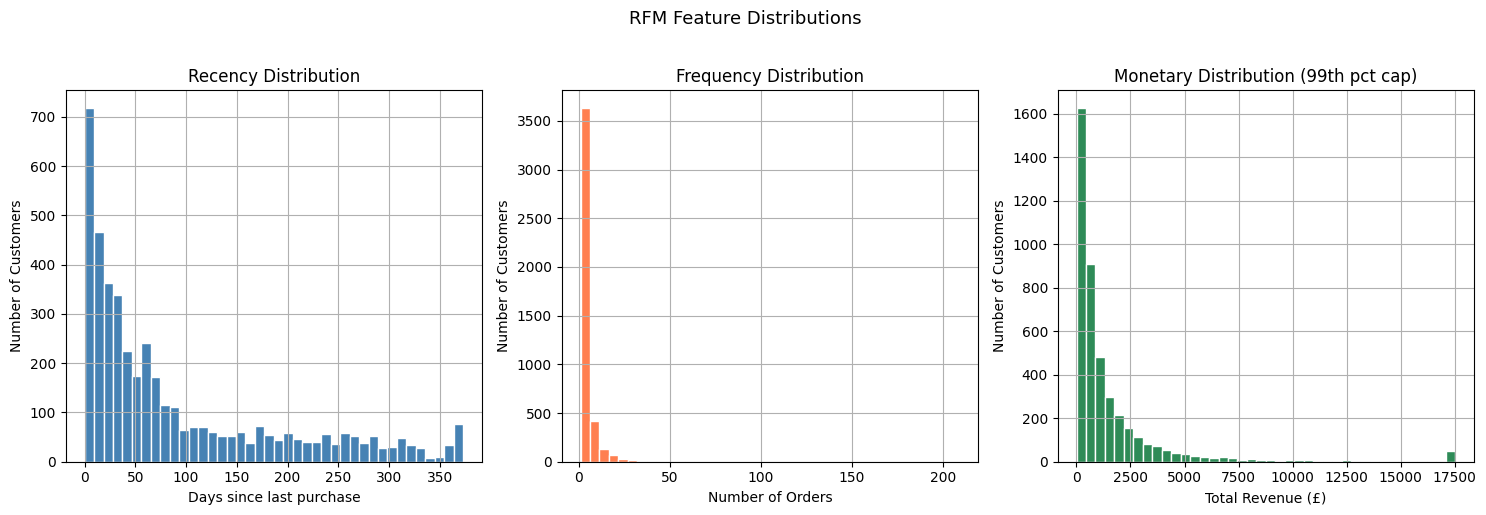

In [73]:
fig, axes = plt.subplots(1, 3, figsize=(15, 5))

rfm['Recency'].hist(bins=40, ax=axes[0], color='steelblue', edgecolor='white')
axes[0].set_title('Recency Distribution')
axes[0].set_xlabel('Days since last purchase')
axes[0].set_ylabel('Number of Customers')

rfm['Frequency'].hist(bins=40, ax=axes[1], color='coral', edgecolor='white')
axes[1].set_title('Frequency Distribution')
axes[1].set_xlabel('Number of Orders')
axes[1].set_ylabel('Number of Customers')

rfm['Monetary'].clip(upper=rfm['Monetary'].quantile(0.99)).hist(bins=40, ax=axes[2], color='seagreen', edgecolor='white')
axes[2].set_title('Monetary Distribution (99th pct cap)')
axes[2].set_xlabel('Total Revenue (£)')
axes[2].set_ylabel('Number of Customers')

plt.suptitle('RFM Feature Distributions', fontsize=13, y=1.02)
plt.tight_layout()
plt.show()

## Step 5: RFM Correlation Heatmap

Understanding correlations between RFM dimensions is important:
- If Frequency and Monetary are highly correlated, they carry similar information
- Low correlation between Recency and Monetary suggests customers who spend a lot don't necessarily buy recently

These relationships affect how the K-Means algorithm clusters customers in Notebook 05.

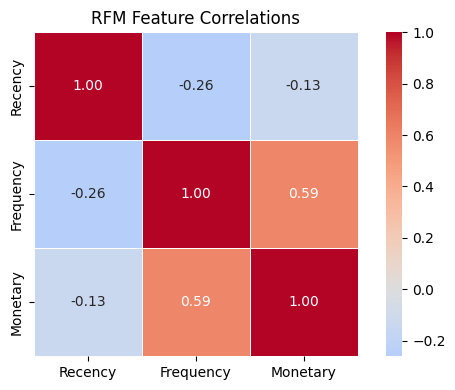

           Recency  Frequency  Monetary
Recency      1.000     -0.261    -0.133
Frequency   -0.261      1.000     0.591
Monetary    -0.133      0.591     1.000


In [77]:
plt.figure(figsize=(6, 4))
corr = rfm[['Recency', 'Frequency', 'Monetary']].corr()
sns.heatmap(corr, annot=True, fmt='.2f', cmap='coolwarm', center=0,
            square=True, linewidths=0.5)
plt.title('RFM Feature Correlations')
plt.tight_layout()
plt.show()
print(corr.round(3))

## Step 6: Save RFM Features

Save the unscaled RFM features - used by Notebook 07 (model training) which needs the raw values to create the target variable.

In [79]:
rfm.to_csv("rfm_features.csv")
print("rfm_features.csv saved.")

rfm_features.csv saved.


## Step 7: Standardise RFM Features

K-Means clustering (used in Notebook 05) is sensitive to the **scale** of features. Because Recency (0 - 365 days), Frequency (1 - 50 orders), and Monetary (£0 - £80,000) are on very different scales, we apply **StandardScaler** to normalise them to zero mean and unit variance before clustering.

Without scaling, Monetary would completely dominate the clustering and Frequency would have almost no effect.

In [81]:
scaler = StandardScaler()
rfm_scaled_array = scaler.fit_transform(rfm)

rfm_scaled = pd.DataFrame(
    rfm_scaled_array,
    index=rfm.index,
    columns=['Recency', 'Frequency', 'Monetary']
)

print("Scaled RFM (mean should be ~0, std should be ~1):")
rfm_scaled.describe().round(3)

Scaled RFM (mean should be ~0, std should be ~1):


,Recency,Frequency,Monetary
count,4331.000,4331.000,4331.000
mean,-0.000,-0.000,0.000
std,1.000,1.000,1.000
min,-0.916,-0.425,-0.237
25%,-0.746,-0.425,-0.201
50%,-0.415,-0.295,-0.157
75%,0.495,0.095,-0.038
max,2.817,26.644,32.566


## Step 8: Save Scaled RFM Features

In [84]:
rfm_scaled.to_csv("rfm_scaled.csv")
print("rfm_scaled.csv saved.")

rfm_scaled.csv saved.


## Summary

| Output | Description |
|--------|-------------|
| `rfm_features.csv` | Raw RFM values per customer (used in NB07 for modelling) |
| `rfm_scaled.csv` | Standardised RFM values (used in NB05 for K-Means clustering) |

**Key characteristics of this customer base:**
- Recency: median customer last bought ~53 days ago - relatively recent
- Frequency: median 3 orders - most customers are occasional buyers
- Monetary: heavily skewed - a few customers drive disproportionate revenue (confirmed by Pareto in NB03)

**Next step:** Notebook 05 will use the scaled RFM features to cluster customers into meaningful segments using K-Means.